# Matching and comparison of the database with external sources

In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import pandas as pd
import ast
import geopandas as gpd
from copy import deepcopy as dc
from matplotlib.ticker import LogLocator, FuncFormatter

import os
import sys
current_dir = os.getcwd()
project_root = os.path.dirname(current_dir)
sys.path.append(project_root)

from src.LLM_functions import *
from src.plot_functions import *
from src.data import *
from src.post_process_functions import *
from src.hazard_def import *
from src.external_comparaison import *

#sys.path.append('/home/lhasbini/como_school/como_project4/src/')

In [3]:
# Import extracted impact
res_name_llm = "post_processed_labelled_reports_meta-llama_llama-4-scout-17b-16e-instruct_v230925"
df_llm = pd.read_csv(os.path.join(DATA_OUT_PROC, res_name_llm+'.csv'), encoding='utf-8')
df_llm_geo = gpd.read_file(os.path.join(DATA_OUT_PROC, res_name_llm+'_geo_v250925.gpkg'))

# df_llm = listify_strings(df_llm)
# df_llm_geo = listify_strings(df_llm_geo)

col_to_list = ["location", "country", "country_kw", "country_iso3", "hazards"]
df_llm[col_to_list] = df_llm[col_to_list].map(lambda x: listify_strings(x))

col_to_list = ["location", "country", "country_kw", "country_iso3", "locationOsm", "locationPolygon", "iso3_code", "hazards"]
df_llm_geo[col_to_list] = df_llm_geo[col_to_list].map(lambda x: listify_strings(x))

#Manually labelled
res_name_labelled = "post_processed_labelled_reports_impacts_all_v240925"
df_labelled = pd.read_csv(os.path.join(DATA_OUT_PROC, res_name_labelled+'.csv'), encoding='utf-8')
df_labelled_geo = gpd.read_file(os.path.join(DATA_OUT_PROC, res_name_labelled+'_geo_v250925.gpkg'))

# df_labelled = listify_strings(df_labelled)
# df_labelled_geo = listify_strings(df_labelled_geo)
col_to_list = ["location", "country", "country_iso3", "hazards"]
df_labelled[col_to_list] = df_labelled[col_to_list].map(lambda x: listify_strings(x))

col_to_list = ["location", "country", "country_iso3", "locationOsm", "locationPolygon", "iso3_code", "hazards"]
df_labelled_geo[col_to_list] = df_labelled_geo[col_to_list].map(lambda x: listify_strings(x))

In [4]:
df_llm_geo_grp = clean_group(df_llm_geo)
df_labelled_geo_grp = clean_group(df_labelled_geo)

In [3]:
# 200 reports 
res_name_llm = "post_processed_monty_200rep_meta-llama_llama-4-scout-17b-16e-instruct_v190925"
df_llm_all = pd.read_csv(os.path.join(DATA_OUT_PROC, res_name_llm+'.csv'), encoding='utf-8')
df_llm_all_geo = gpd.read_file(os.path.join(DATA_OUT_PROC, res_name_llm+'_geo_v260925.gpkg'))

col_to_list = ["location", "country", "country_kw", "country_iso3", "hazards"]
df_llm_all[col_to_list] = df_llm_all[col_to_list].map(lambda x: listify_strings(x))

col_to_list = ["location", "country", "country_kw", "country_iso3", "locationOsm", "locationPolygon", "iso3_code", "hazards"]
df_llm_all_geo[col_to_list] = df_llm_all_geo[col_to_list].map(lambda x: listify_strings(x))


In [7]:
df_llm_all_geo_grp = clean_group(df_llm_all_geo, ADM_min=0)

In [8]:
# Import data from other sources
df_ifrc_go = open_clean_ifrc_go()
df_ifrc_monty = open_clean_ifrc_monty(df_ifrc_go)

df_external_source = {}
df_external_source["ifrc_go"] = df_ifrc_go
df_external_source["ifrc_monty"] = df_ifrc_monty

In [43]:
df_external_source["ifrc_go"]["appealCode"].nunique()

2050

In [46]:
df_llm_all_geo_grp.loc[df_llm_all_geo_grp["appealCode"].isin(df_external_source["ifrc_go"]["appealCode"].unique())]["appealCode"].nunique()

142

In [9]:
df_llm_all_geo_grp_linked = {}

In [10]:
# Matching with IFRC MONTY df_llm 
df_ifrc_monty_subset = df_ifrc_monty[["appealCode", "impact_type", "impact_value", "impact_category"]]
df_llm_all_geo_grp_linked["ifrc_monty"] = df_llm_all_geo_grp.merge(df_ifrc_monty_subset, left_on=["appealCode", "impactSubtype"], right_on=["appealCode", "impact_type"])

In [11]:
# Filter columns, DREF reports with appealCode
df_llm_all_geo_grp_linked["ifrc_go"] = df_llm_all_geo_grp.merge(df_ifrc_go, on=["appealCode"])

# Matching with EM-DAT

In [12]:
#Open EM-DAT
df_em_dat = pd.read_excel(DATA_EXTERNAL_SOURCE / 'public_emdat_custom_request_2025-08-19.xlsx')
df_em_dat = df_em_dat.loc[df_em_dat["Disaster Type"].isin(hazard_mapping_emdat.keys())]
# df_em_dat = df_em_dat[["DisNo.", "Disaster Type", 'Country', 'Subregion', 'Region', 'Location',
#                        'Start Year', 'Start Month', 'Start Day', 'End Year', 'End Month', 'End Day',
#                        'Total Deaths', 'No. Injured', 'No. Affected', 'No. Homeless',
#                        'Total Affected', "Reconstruction Costs ('000 US$)",
#                        "Reconstruction Costs, Adjusted ('000 US$)", "Insured Damage ('000 US$)", "Insured Damage, Adjusted ('000 US$)",
#                        "Total Damage ('000 US$)", "Total Damage, Adjusted ('000 US$)"]]

df_em_dat["Start Month"] = df_em_dat["Start Month"].fillna(1).astype(int)
df_em_dat["Start Day"] = df_em_dat["Start Day"].fillna(1).astype(int)
df_em_dat["Start Date"] = pd.to_datetime(
    df_em_dat[["Start Year", "Start Month", "Start Day"]].rename(
        columns={"Start Year": "year", "Start Month": "month", "Start Day": "day"}
    ),
    errors="coerce"
)

df_em_dat["End Month"] = df_em_dat["End Month"].fillna(1).astype(int)
df_em_dat["End Day"] = df_em_dat["End Day"].fillna(1).astype(int)
df_em_dat["End Date"] = pd.to_datetime(
    df_em_dat[["End Year", "End Month", "End Day"]].rename(
        columns={"End Year": "year", "End Month": "month", "End Day": "day"}
    ),
    errors="coerce"
)

df_external_source["emdat"] = df_em_dat

In [13]:
# Test the matching method 
df_llm_all_geo_linked = {}
df_llm_em_dat = {}

month_list = [2, 3, 6, 12]
# date_diff_th_list = [datetime.timedelta(days=2*30), datetime.timedelta(days=3*30), datetime.timedelta(days=6*30)]
for months in month_list :
    date_diff_th = datetime.timedelta(days=months*30)
    df_llm_all_geo_linked[months], df_llm_em_dat[months] = matching_emdat(df_llm_all_geo_grp, df_em_dat, date_diff_th, "date_diff_start")

c:\Users\lhasbini\ownCloud\Documents\Thèse\programs\como_project4\como_project4\src\external_comparaison.py:379: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: choose_unique_disno(x, column_minimize))
c:\Users\lhasbini\ownCloud\Documents\Thèse\programs\como_project4\como_project4\src\external_comparaison.py:379: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: choose_unique_disno(x, colu

In [14]:
appeal_disno_links = {}
for months in month_list :
    appeal_disno_links = (
        df_llm_em_dat[months].groupby("appealCode")["DisNo."]
        .agg(num_DisNo="nunique", list_DisNo=lambda x: list(set(x)))
        .reset_index()
        .sort_values(by="num_DisNo", ascending=False)
    )

In [15]:
df_merge = {}
impactSubtype = "Affected People" #"Affected People" "Human Deaths" 
for months in month_list :
    df_merge[months] = match_impact_values(df_llm_all_geo_linked[months], impactSubtype)

    # Add errors metrics
    df_merge[months]["error"] = df_merge[months]["EM-DAT"] - df_merge[months]["LLM_extracted"]

    df_merge[months]["abs_relative_error"] = np.abs(df_merge[months]["LLM_extracted"] - df_merge[months]["EM-DAT"])/df_merge[months]["LLM_extracted"]

    df_merge[months]["abs_error"] = (df_merge[months]["LLM_extracted"] - df_merge[months]["EM-DAT"]).abs()

    # Squared error per row (for RMSE)
    df_merge[months]["squared_error"] = (df_merge[months]["LLM_extracted"] - df_merge[months]["EM-DAT"])**2

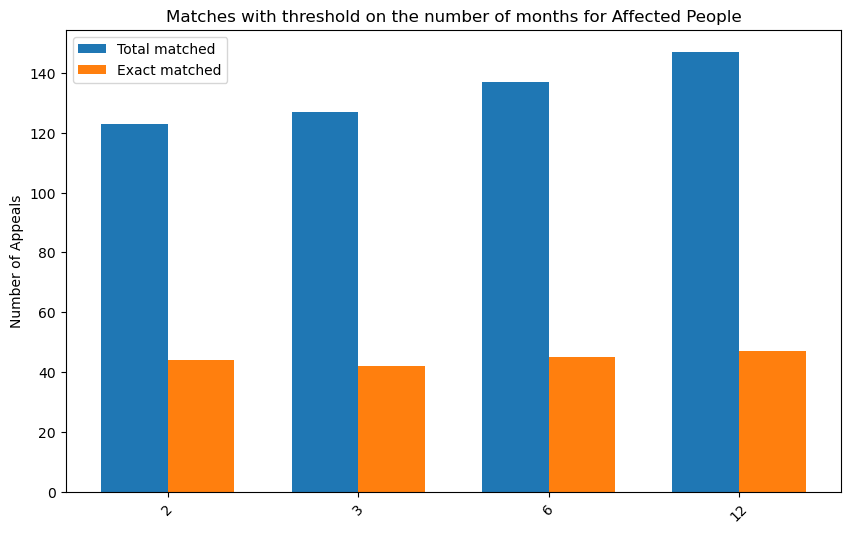

In [25]:
totals = []
exact_matches = []

for m in month_list:
    df_m = df_merge[m]
    totals.append(len(df_m))
    exact_matches.append(len(df_m.loc[df_m["match"]]))

x = np.arange(len(month_list))  # positions for bars
width = 0.35  # bar width

fig, ax = plt.subplots(figsize=(10,6))

# Bars
bars1 = ax.bar(x - width/2, totals, width, label="Total matched")
bars2 = ax.bar(x + width/2, exact_matches, width, label="Exact matched")

# Labels
ax.set_xticks(x)
ax.set_xticklabels(month_list, rotation=45)
ax.set_ylabel("Number of Appeals")
ax.set_title(f"Matches with threshold on the number of months for {impactSubtype}")
ax.legend()

plt.show()

In [174]:
df_merge[2].head()

,appealCode,LLM_extracted,EM-DAT,match,error,abs_relative_error,abs_error,squared_error
0,MDR43007,7500000.0,4566584.0,False,-2933416.0,0.391122,2933416.0,8.604929e+12
1,MDRAF007,382.0,569240.0,False,568858.0,1489.157068,568858.0,3.235994e+11
2,MDRAF008,30800.0,30833.0,False,33.0,0.001071,33.0,1.089000e+03
3,MDRAF009,4200.0,4200.0,True,0.0,0.000000,0.0,0.000000e+00
4,MDRAF010,10500.0,4004.0,False,-6496.0,0.618667,6496.0,4.219802e+07


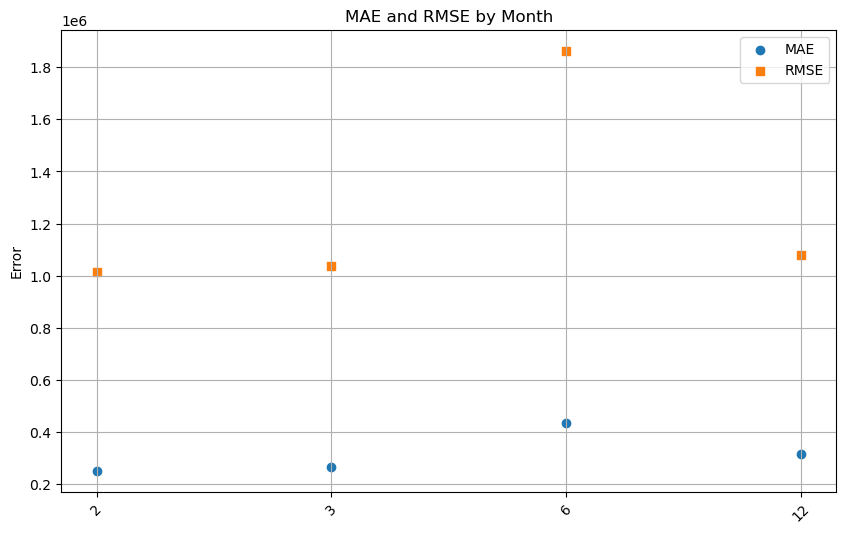

In [173]:
mae_list = []
rmse_list = []

for m in month_list:
    df_m = df_merge[m]  
    if len(df_m) == 0:
        mae_list.append(np.nan)
        rmse_list.append(np.nan)
        continue
    
    mae = df_m["abs_error"].mean()
    rmse = np.sqrt(df_m["squared_error"].mean())
    
    mae_list.append(mae)
    rmse_list.append(rmse)

x = np.arange(len(month_list))

plt.figure(figsize=(10,6))
plt.scatter(x, mae_list, marker="o", label="MAE")
plt.scatter(x, rmse_list, marker="s", label="RMSE")

plt.xticks(x, month_list, rotation=45)
plt.ylabel("Error")
plt.title("MAE and RMSE by Month")
plt.legend()
plt.grid(True)
plt.show()

In [57]:
#MDRCN006
#MDRBR010

df_llm_em_dat.loc[(df_llm_em_dat["appealCode"]=="MDRCD030") & (df_llm_em_dat["impactSubtype"]==impactType)][["impactValue_final", "impactUnit", "reportDate", "hazards", 
                                                                                                            #  'startYear', 'startMonth', 'startDay',
                                                                                                            #  'endYear', 'endMonth', 'endDay', 
                                                                                                            "External IDs", 
                                                                                                             emdat_col, "Entry Date", "Disaster Type", "Disaster Subtype","DisNo.", 
                                                                                                             'startYear', 'Start Month', 'Start Day', 
                                                                                                             'End Year', 'End Month', 'End Day', "Subregion", "Location"]]

,impactValue_final,impactUnit,reportDate,hazards,External IDs,Total Affected,Entry Date,Disaster Type,Disaster Subtype,DisNo.,startYear,Start Month,Start Day,End Year,End Month,End Day,Subregion,Location


In [138]:
appeal_test_error = df_merge[2].sort_values(by="abs_relative_error", ascending=False).iloc[:20]['appealCode']

In [141]:
df_merge[2].loc[df_merge[2]["appealCode"].isin(appeal_test_error)][["appealCode", "LLM_extracted", "EM-DAT", "error", "abs_relative_error", "abs_error"]].sort_values(by="abs_relative_error", ascending=False)

,appealCode,LLM_extracted,EM-DAT,error,abs_relative_error,abs_error
57,MDRET037,0.0,2.0,2.0,inf,2.0
54,MDRET017,8.0,100.0,92.0,11.500000,92.0
32,MDRCF029,2.0,16.0,14.0,7.000000,14.0
15,MDRBD017,14.0,106.0,92.0,6.571429,92.0
11,MDRAR023,18.0,125.0,107.0,5.944444,107.0
16,MDRBD023,9.0,40.0,31.0,3.444444,31.0
29,MDRBY007,10.0,43.0,33.0,3.300000,33.0
21,MDRBF013,4.0,15.0,11.0,2.750000,11.0
12,MDRAR024,3.0,9.0,6.0,2.000000,6.0
50,MDREC027,14.0,42.0,28.0,2.000000,28.0


In [184]:
df_llm_all_geo_linked[2].loc[(df_llm_all_geo_linked[2]["appealCode"]=="MDRAF007") & (df_llm_all_geo_linked[2]["impactSubtype"]==impactSubtype)][["impactValue", "impactSubtype", mapping_impact_type[impactSubtype]["emdat"]]]

,impactValue,impactSubtype,Total Affected
25,382.0,Affected People,569240.0


In [190]:
df_llm_em_dat[2].loc[(df_llm_em_dat[2]["appealCode"]=="MDRAF007")][["appealCode", "impactValue", "impactSubtype", mapping_impact_type[impactSubtype]["emdat"], "DisNo."]]

,appealCode,impactValue,impactSubtype,Total Affected,DisNo.
59023,MDRAF007,2000.0,Human Deaths,569240.0,2023-0636-AFG
59032,MDRAF007,2000.0,Human Deaths,140.0,2023-0660-AFG


In [192]:
df_llm_all_geo.loc[(df_llm_all_geo["appealCode"]=="MDRAF007") & (df_llm_all_geo["impactSubtype"]==impactSubtype)]

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,country,location,locationAnnotation,...,country_iso3,country_iso3_kw,unit_type,locationLowestAdmin,geocoding_country_flag,geocoding_osm_flag,locationOsm,locationPolygon,iso3_code,geometry
93,Affected People,NaN,NaN,NaN,None,None,"['The impact was particularly severe in Herat,...",[Afghanistan],"[Herat, Badghis, Farah, Ghor, Ghoryan, Gulran,...","['The impact was particularly severe in Herat,...",...,[AFG],AFG,other,ADM_0,1,6,"[Herat, Badghis Province, Farah Province, Ghor...","[Afghanistan, Afghanistan, Afghanistan, Afghan...",[AFG],"MULTIPOLYGON (((64.40479 29.54812, 64.40461 29..."
104,Affected People,382.0,NaN,NaN,exact,villages,['The Afghanistan National Disaster Management...,[Afghanistan],"[Ghoryan, Gulran, Guzara, Herat, Injil, Karukh...",['The Afghanistan National Disaster Management...,...,[AFG],AFG,other,ADM_0,1,6,"[Herat, Ghurian, Gulran, Guzara, Injil, Karukh...","[Afghanistan, Afghanistan, Afghanistan, Afghan...",[AFG],"MULTIPOLYGON (((64.40488 29.54819, 64.40479 29..."


In [175]:
df_llm_em_dat[2].loc[(df_llm_em_dat[2]["appealCode"]=="MDRAF007") & (df_llm_em_dat[2]["impactSubtype"]==impactSubtype)][["impactValue", "impactSubtype", mapping_impact_type[impactSubtype]["emdat"], 
                                                                                                                               "startDate", "endDate", "location",
                                                                                                                               "Start Date", "End Date", "Location",
                                                                                                                               "date_diff_start", "date_diff_end", "date_diff_mean"]]

,impactValue,impactSubtype,Total Affected,startDate,endDate,location,Start Date,End Date,Location,date_diff_start,date_diff_end,date_diff_mean


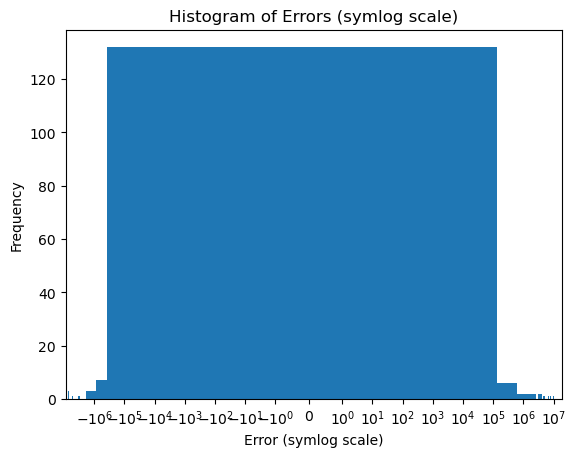

In [119]:
df_merge["error"].plot(kind="hist", bins=50)
# plt.xscale("symlog", linthresh=10**4)
plt.xscale("symlog", linthresh=1)
plt.xlabel("Error (symlog scale)")
plt.ylabel("Frequency")
plt.title("Histogram of Errors (symlog scale)")
plt.show()

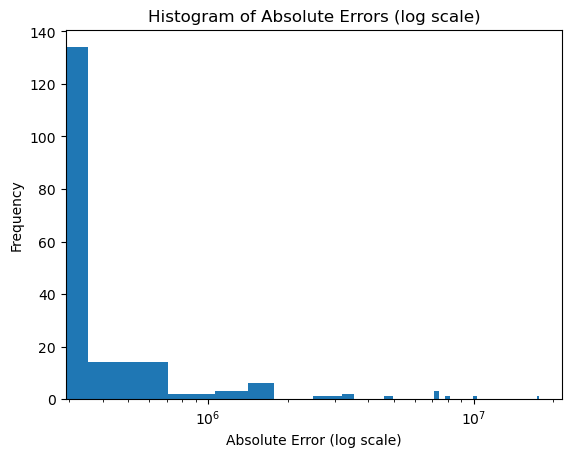

In [27]:
df_merge["abs_error"].plot(kind="hist", bins=50)  # you can adjust bins for resolution
plt.xscale("log")
plt.xlabel("Absolute Error (log scale)")
plt.ylabel("Frequency")
plt.title("Histogram of Absolute Errors (log scale)")
plt.show()

In [ ]:
# Make the global plot with :
# - ImpactSubtypes in the x axis
# - Several bar plot for the error per Impact Subtype
# - Another plot with coverage, corresponding to the number of reports we manage to link with our criterias 

200

# Global plots

Need to plot informations about the raw dataset, such as : 
- Map with the number of event per country --> Need to filter over the same period 
- Total number of affected people (per year per country ?)
- % of reports for which we have information about each Impact Category (before matching with the ones extracted with LLM)

### Plot of % of reports with impact information 

In [11]:
df_external_source["ifrc_go"]["disaster_start_date"] = pd.to_datetime(df_external_source["ifrc_go"]["disaster_start_date"],
    errors='coerce')

In [12]:
nb_report_with_impact = {}
perc_report_with_impact = {}

In [ ]:
external_source = "ifrc_go"

nb_report_with_impact[external_source] = []
perc_report_with_impact[external_source] = []

df_impact_ext = df_external_source[external_source].loc[
    (df_external_source[external_source]["end_datetime"] > datetime.datetime(year=2000, month=1, day=1)) &
    (df_external_source[external_source]["start_datetime"] < datetime.datetime(year=2000, month=1, day=1))
]

for impactSubtype in mapping_impact_type.keys() : 
    col = mapping_impact_type[impactSubtype]['ifrc_go']
    if col is None :
        nb_report_with_impact[external_source].append(0)
        perc_report_with_impact[external_source].append(0)
        continue
    n = len(df_impact_ext.dropna(subset=impactSubtype))
    nb_report_with_impact[external_source].append(n)
    perc_report_with_impact[external_source].append(n/len(df_impact_ext))


In [76]:
df_external_source[external_source]["end_datetime"] = pd.to_datetime(df_external_source[external_source]["end_datetime"], errors='coerce')
df_external_source[external_source]["start_datetime"] = pd.to_datetime(df_external_source[external_source]["start_datetime"], errors='coerce')

In [ ]:
external_source = "ifrc_monty"

nb_report_with_impact[external_source] = []
perc_report_with_impact[external_source] = []

df_impact_ext = df_external_source[external_source].loc[
    (df_external_source[external_source]["end_datetime"] > pd.Timestamp("2000-01-01", tz="UTC")) &
    (df_external_source[external_source]["start_datetime"] < pd.Timestamp("2025-01-01", tz="UTC"))
]

for impactSubtype in mapping_impact_type.keys() : 
    col = mapping_impact_type[impactSubtype]['ifrc_monty']
    if col is None :
        nb_report_with_impact[external_source].append(0)
        perc_report_with_impact[external_source].append(0)
        continue
    n = df_impact_ext.loc[df_impact_ext["impact_type"]==impactSubtype].dropna(subset=["impact_value"])["appealCode"].nunique()
    nb_report_with_impact[external_source].append(n)
    perc_report_with_impact[external_source].append(n/len(df_impact_ext))


In [43]:
external_source = "emdat"

nb_report_with_impact[external_source] = []
perc_report_with_impact[external_source] = []

df_impact_ext = df_external_source[external_source].loc[
    (df_external_source[external_source]["End Date"] > datetime.datetime(year=2000, month=1, day=1)) &
    (df_external_source[external_source]["Start Date"] < datetime.datetime(year=2000, month=1, day=1))
]

for impactSubtype in mapping_impact_type.keys() : 
    col = mapping_impact_type[impactSubtype]['emdat']
    if col is None :
        nb_report_with_impact[external_source].append(0)
        perc_report_with_impact[external_source].append(0)
        continue
    n = len(df_impact_ext.dropna(subset=col))
    nb_report_with_impact[external_source].append(n)
    perc_report_with_impact[external_source].append(n/len(df_impact_ext))


In [55]:
nb_report_with_impact_llm = []
perc_report_with_impact_llm = []

for impactSubtype in mapping_impact_type.keys() : 
    df_impact_ext = df_llm_all_geo_grp.loc[df_llm_all_geo_grp["impactSubtype"]==impactSubtype]
    n = df_impact_ext.dropna(subset="impactValue_final")["appealCode"].nunique()
    nb_report_with_impact_llm.append(n)
    perc_report_with_impact_llm.append(n/df_llm_all_geo_grp["appealCode"].nunique())


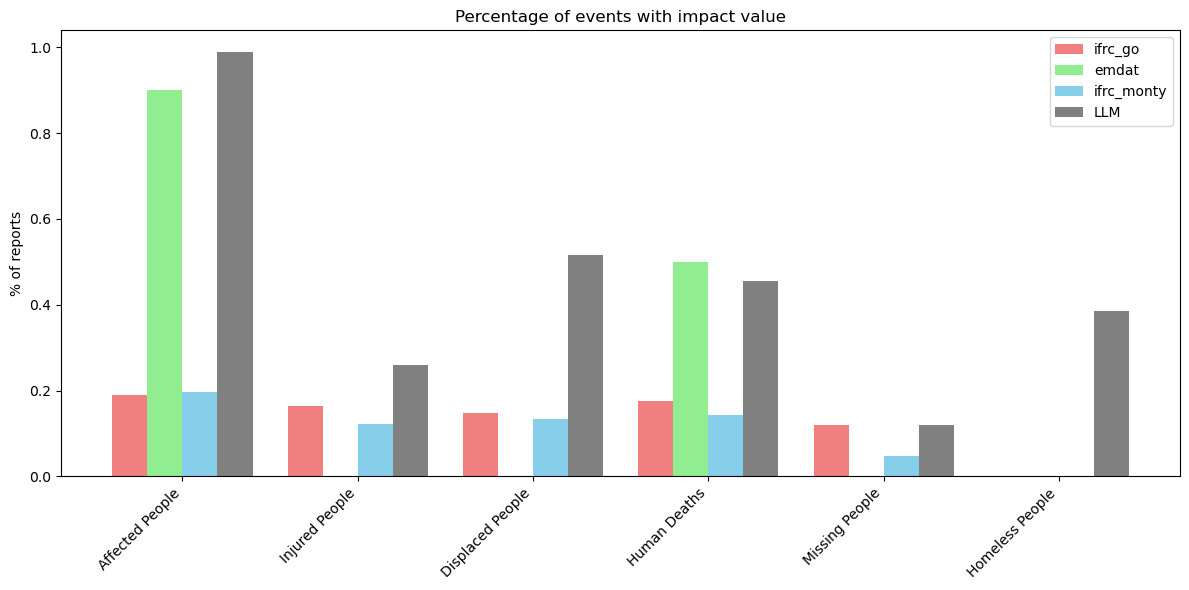

In [80]:
x = np.arange(len(mapping_impact_type.keys()))  # positions for bars
width = 0.2  # bar width

fig, ax = plt.subplots(figsize=(12,6))

# Define colors like in your previous example
colors = {}
colors["ifrc_monty"] = ["skyblue", "dodgerblue"]      # all / perfect match
colors["emdat"] = ["lightgreen", "green"]       # all / perfect match
colors["ifrc_go"] = ["lightcoral", "brown"]

for i, external_source in enumerate(perc_report_with_impact.keys()) : 
    # IFRC bars
    ax.bar(x + (i-1)*width- width/2, perc_report_with_impact[external_source], width, label=external_source, color=colors[external_source][0])

ax.bar(x + 2*width - width/2, perc_report_with_impact_llm, width, label="LLM", color="grey")
# Labels
ax.set_xticks(x)
ax.set_xticklabels(mapping_impact_type.keys(), rotation=45, ha="right")
ax.set_ylabel(r"% of reports")
ax.set_title(r"Percentage of events with impact value")
ax.legend()

plt.tight_layout()
plt.show()

## Bar Plot after event matching

In [16]:
df_llm_all_geo_grp_linked["emdat"] = df_llm_all_geo_linked[2]

In [17]:
nb_matched = {}
nb_exact_match = {}
nb_no_match = {}
nb_no_external_impact = {}

In [37]:
df_llm_all_geo_grp["appealCode"].nunique()

200

In [35]:
df_llm_all_geo_grp_linked["ifrc_monty"]["appealCode"].nunique()

60

In [18]:
# Number mapped and nb with exact matching 
external_source = "ifrc_monty"
nb_matched[external_source] = []
nb_exact_match[external_source] = []

df_llm_all_geo_grp_linked[external_source]["match"] = (df_llm_all_geo_grp_linked[external_source]["impact_value"]==df_llm_all_geo_grp_linked[external_source]["impactValue_final"])

for impactSubtype in mapping_impact_type.keys() : 
    col = mapping_impact_type[impactSubtype]['ifrc_monty']
    if col is None :
        nb_matched[external_source].append(0)
        nb_exact_match[external_source].append(0)
        continue

    df_matched = df_llm_all_geo_grp_linked[external_source].loc[df_llm_all_geo_grp_linked[external_source]["impactSubtype"] == impactSubtype]
    nb_matched[external_source].append(df_matched["appealCode"].nunique())
    nb_exact_match[external_source].append(df_matched.loc[df_matched["match"]]["appealCode"].nunique())

In [19]:
# Number mapped and nb with exact matching 
external_source = "ifrc_go"
nb_matched[external_source] = []
nb_exact_match[external_source] = []
nb_no_external_impact[external_source] = []

for impactSubtype in mapping_impact_type.keys() : 
    col = mapping_impact_type[impactSubtype]['ifrc_go']
    if col is None :
        nb_matched[external_source].append(0)
        nb_exact_match[external_source].append(0)
        nb_no_external_impact[external_source].append(0)
        continue

    df_matched = df_llm_all_geo_grp_linked[external_source].loc[df_llm_all_geo_grp_linked[external_source]["impactSubtype"] == impactSubtype]
    n_before = len(df_matched)
    df_matched = df_matched.dropna(subset=[impactSubtype])
    n_after = len(df_matched)
    
    df_matched["match"] = (df_matched["impactValue"]==df_matched[impactSubtype])
    
    
    nb_no_external_impact[external_source].append(n_before-n_after)
    nb_matched[external_source].append(df_matched["appealCode"].nunique())
    nb_exact_match[external_source].append(df_matched.loc[df_matched["match"]]["appealCode"].nunique())

In [20]:
# Number mapped and nb with exact matching 
external_source = "emdat"
nb_matched[external_source] = []
nb_exact_match[external_source] = []
nb_no_external_impact[external_source] = []

for impactSubtype in mapping_impact_type.keys() : 
    emdat_col = mapping_impact_type[impactSubtype]['emdat']
    if emdat_col is None :
        nb_matched[external_source].append(0)
        nb_exact_match[external_source].append(0)
        nb_no_external_impact[external_source].append(0)
        continue

    df_matched = df_llm_all_geo_grp_linked[external_source].loc[df_llm_all_geo_grp_linked[external_source]["impactSubtype"] == impactSubtype]
    n_before = len(df_matched)
    df_matched = df_matched.dropna(subset=[mapping_impact_type[impactSubtype]["emdat"]])
    n_after = len(df_matched)

    df_matched["match"] = (df_matched["impactValue"]==df_matched[mapping_impact_type[impactSubtype]["emdat"]])
    
    nb_no_external_impact[external_source].append(n_before-n_after)
    nb_matched[external_source].append(df_matched["appealCode"].nunique())
    nb_exact_match[external_source].append(df_matched.loc[df_matched["match"]]["appealCode"].nunique())

In [21]:
nb_extracted = []
for impactSubtype in mapping_impact_type.keys() : 
    nb_extracted.append(df_llm_all_geo_grp.loc[df_llm_all_geo_grp["impactSubtype"]==impactSubtype].dropna(subset=["impactValue_final"])["appealCode"].nunique())

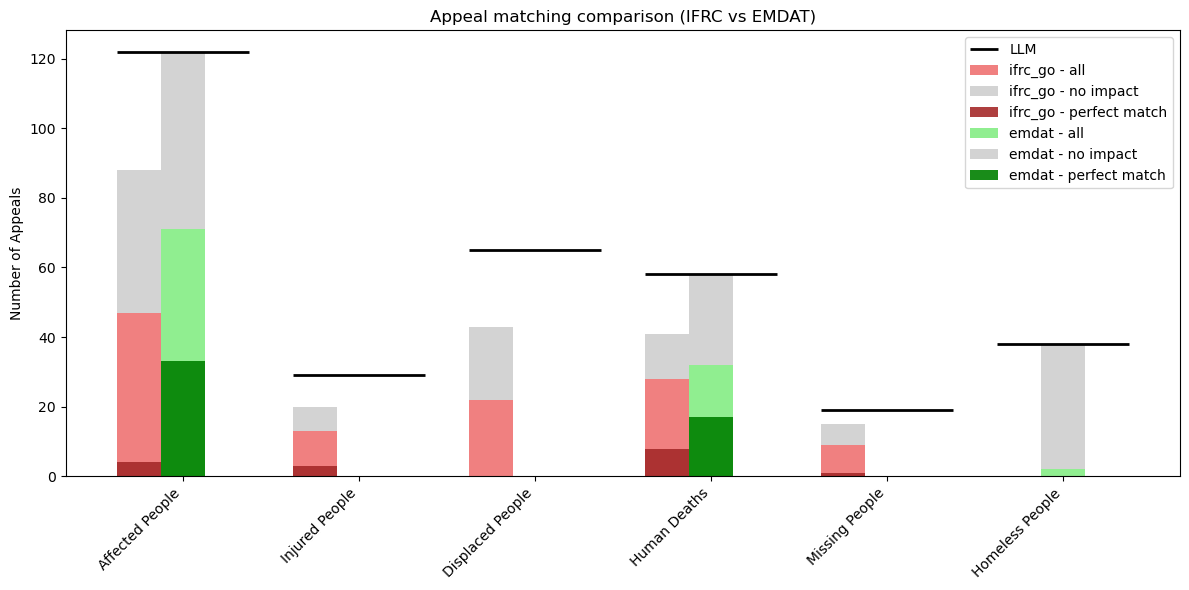

In [22]:
x = np.arange(len(mapping_impact_type.keys()))  # positions for bars
width = 0.25  # bar width

fig, ax = plt.subplots(figsize=(12,6))

# Define colors
colors = {
    "ifrc_monty": ["skyblue", "dodgerblue"],
    "emdat": ["lightgreen", "green"],
    "ifrc_go": ["lightcoral", "brown"],
}

for i, external_source in enumerate(["ifrc_go", "emdat"]):
    # Base bars ("all")
    bars_all = ax.bar(
        x + (i-1)*width,
        nb_matched[external_source],
        width,
        label=external_source + " - all",
        color=colors[external_source][0],
    )

    # Add stacked bar ("no external impact") on top of "all"
    ax.bar(
        x + (i-1)*width,
        nb_no_external_impact[external_source],
        width,
        bottom=nb_matched[external_source],
        label=external_source + " - no impact",
        color="lightgray",
        # edgecolor="gray",
    )

    # "Perfect match" bars
    ax.bar(
        x + (i-1)*width,
        nb_exact_match[external_source],
        width,
        label=external_source + " - perfect match",
        color=colors[external_source][1],
        alpha=0.9,
    )

# Target lines
total_bar_width = 3*width
for xi, y in zip(x, nb_extracted):
    ax.hlines(
        y=y,
        xmin=xi - total_bar_width/2,
        xmax=xi + total_bar_width/2,
        colors='black',
        linewidth=2,
        label="LLM" if xi == 0 else ""
    )

# Labels and formatting
ax.set_xticks(x)
ax.set_xticklabels(mapping_impact_type.keys(), rotation=45, ha="right")
ax.set_ylabel("Number of Appeals")
ax.set_title("Appeal matching comparison (IFRC vs EMDAT)")
ax.legend()
plt.tight_layout()
plt.show()


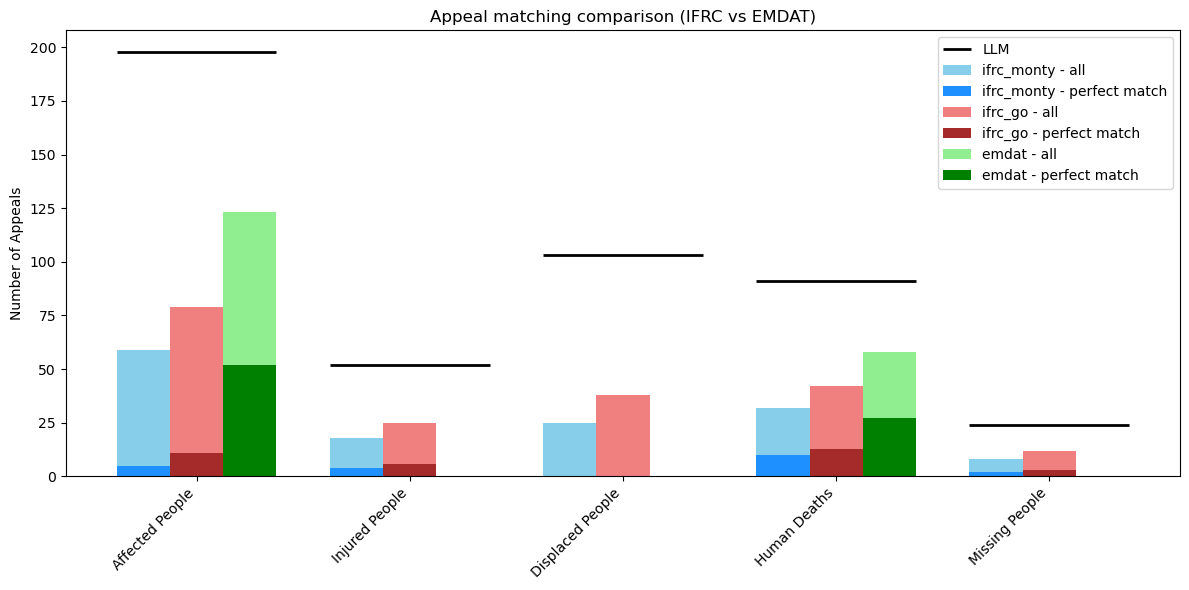

In [111]:
x = np.arange(len(mapping_impact_type.keys()))  # positions for bars
width = 0.25  # bar width

fig, ax = plt.subplots(figsize=(12,6))

# Define colors like in your previous example
colors = {}
colors["ifrc_monty"] = ["skyblue", "dodgerblue"]      # all / perfect match
colors["emdat"] = ["lightgreen", "green"]       # all / perfect match
colors["ifrc_go"] = ["lightcoral", "brown"]

for i, external_source in enumerate(nb_matched.keys()) : 
    # IFRC bars
    ax.bar(x + (i-1)*width, nb_matched[external_source], width, label=external_source+" - all", color=colors[external_source][0])
    ax.bar(x + (i-1)*width, nb_exact_match[external_source], width, label=external_source+" - perfect match", color=colors[external_source][1])

    # # EMDAT bars
    # ax.bar(x + (i-1)*width, nb_matched_emdat, width, label="EMDAT - all", color=colors_emdat[0])
    # ax.bar(x + (i-1)*width, nb_exact_match_emdat, width, label="EMDAT - perfect match", color=colors_emdat[1])

    # # EMDAT bars
    # ax.bar(x + (i-1)*width, nb_matched_emdat, width, label="EMDAT - all", color=colors_emdat[0])
    # ax.bar(x + (i-1)*width, nb_exact_match_emdat, width, label="EMDAT - perfect match", color=colors_emdat[1])

# Target
total_bar_width = 3*width
for xi, y in zip(x, nb_extracted):
    ax.hlines(y=y, xmin=xi - total_bar_width/2, xmax=xi + total_bar_width/2,
              colors='black', linewidth=2, label="LLM" if xi == 0 else "")


# Labels
ax.set_xticks(x)
ax.set_xticklabels(mapping_impact_type.keys(), rotation=45, ha="right")
ax.set_ylabel("Number of Appeals")
ax.set_title("Appeal matching comparison (IFRC vs EMDAT)")
ax.legend()

plt.tight_layout()
plt.show()

In [88]:
columns = ["appealCode", "locationLowestAdmin", "impactValue", "Affected People", "reportDate", "reportLink", "appeals_start_date", "appeals_status", "created_at", "updated_at"]
df_llm_all_geo_grp_linked["ifrc_go"].loc[(df_llm_all_geo_grp_linked["ifrc_go"]["impactSubtype"] == "Affected People") & (df_llm_all_geo_grp_linked["ifrc_go"]["impactValue"] != df_llm_all_geo_grp_linked["ifrc_go"]["Affected People"])][columns].dropna(subset=["Affected People"]).head(50)

,appealCode,locationLowestAdmin,impactValue,Affected People,reportDate,reportLink,appeals_start_date,appeals_status,created_at,updated_at
22,MDRAF014,ADM_1,325205.000,5404.0,2024-12-31,https://go-api.ifrc.org/api/downloadfile/87310...,2024-03-16T00:00:00Z,1.0,2024-03-04T18:35:28.334985Z,2024-03-04T18:35:28.334998Z
58,MDRAM006,ADM_2,3000.000,1400.0,2021-04-29,https://adore.ifrc.org/Download.aspx?FileId=40...,2020-07-24T00:00:00Z,1.0,2020-07-15T13:42:06.009861Z,2020-07-15T13:42:06.009881Z
62,MDRAM011,ADM_1,18000.000,16860.0,2024-12-23,https://go-api.ifrc.org/api/downloadfile/84731...,2023-06-29T00:00:00Z,1.0,2023-06-17T10:09:08.187506Z,2024-06-03T18:12:06.293802Z
69,MDRAM013,ADM_1,30000.000,5500.0,2025-03-19,https://go-api.ifrc.org/api/downloadfile/87990...,2024-06-10T00:00:00Z,1.0,2024-05-27T12:47:22.079758Z,2024-09-20T06:25:51.154850Z
78,MDRAO008,ADM_1,116275.000,25602.0,2025-06-17,https://go-api.ifrc.org/api/downloadfile/86312...,2023-12-10T00:00:00Z,1.0,2023-11-29T16:53:48.564431Z,2023-12-13T08:33:58.701627Z
109,MDRAR016,ADM_1,31651.000,3500.0,2019-09-05,https://adore.ifrc.org/Download.aspx?FileId=25...,2019-01-27T00:00:00Z,1.0,2019-01-17T11:49:29.422643Z,2019-12-30T07:52:29.316631Z
121,MDRAR019,ADM_0,38000.000,90000.0,2024-05-31,https://adore.ifrc.org/Download.aspx?FileId=83...,2023-06-06T00:00:00Z,1.0,2023-05-29T19:57:02.381140Z,2024-06-03T12:41:04.969399Z
129,MDRAR020,ADM_0,8000.000,100000.0,2025-03-26,https://go-api.ifrc.org/api/downloadfile/86586...,2023-12-28T00:00:00Z,1.0,2023-12-17T04:54:17.600294Z,2023-12-17T04:54:17.600307Z
136,MDRAR021,ADM_0,400000.000,17500.0,2025-05-28,https://go-api.ifrc.org/api/downloadfile/87306...,2024-03-14T00:00:00Z,1.0,2024-03-05T23:28:52.906793Z,2024-03-05T23:28:52.906805Z
140,MDRAR023,ADM_1,235900.000,169000.0,2025-05-30,https://go-api.ifrc.org/api/downloadfile/91294...,2025-03-15T00:00:00Z,0.0,2025-03-07T13:52:18.620169Z,2025-03-07T13:52:18.620226Z


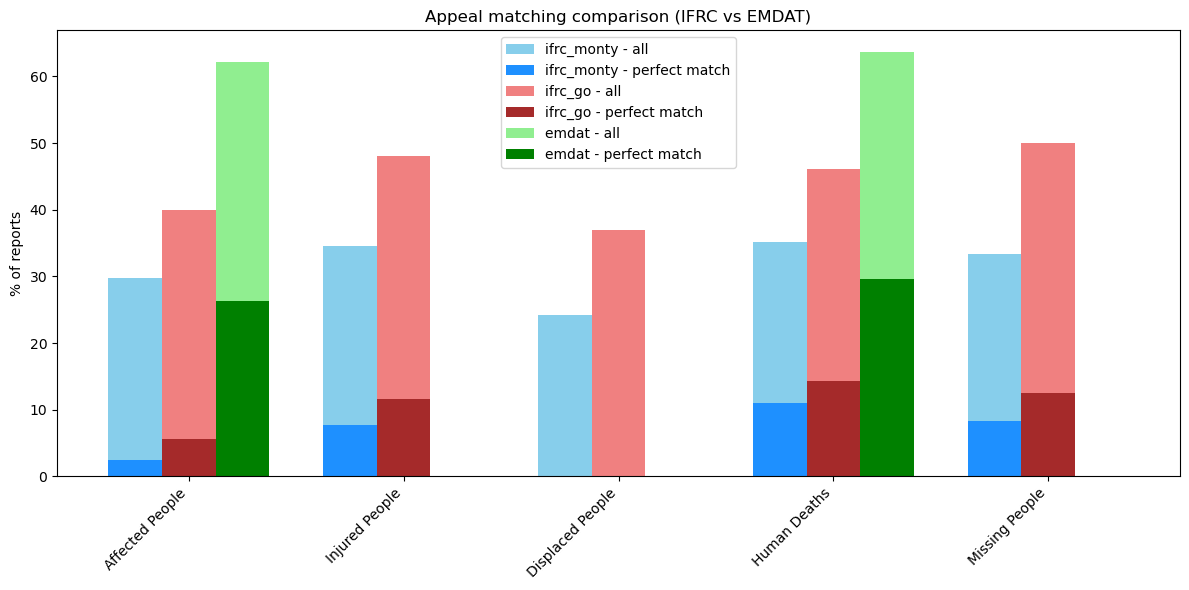

In [105]:
x = np.arange(len(mapping_impact_type.keys()))  # positions for bars
width = 0.25  # bar width

fig, ax = plt.subplots(figsize=(12,6))

# Define colors like in your previous example
colors = {}
colors["ifrc_monty"] = ["skyblue", "dodgerblue"]      # all / perfect match
colors["emdat"] = ["lightgreen", "green"]       # all / perfect match
colors["ifrc_go"] = ["lightcoral", "brown"]

for i, external_source in enumerate(nb_matched.keys()) : 
    # IFRC bars
    ax.bar(x + (i-1)*width, [100*matched / extracted for matched, extracted in zip(nb_matched[external_source], nb_extracted)], width, label=external_source+" - all", color=colors[external_source][0])
    ax.bar(x + (i-1)*width, [100*matched / extracted for matched, extracted in zip(nb_exact_match[external_source], nb_extracted)], width, label=external_source+" - perfect match", color=colors[external_source][1])

    # # EMDAT bars
    # ax.bar(x + (i-1)*width, nb_matched_emdat, width, label="EMDAT - all", color=colors_emdat[0])
    # ax.bar(x + (i-1)*width, nb_exact_match_emdat, width, label="EMDAT - perfect match", color=colors_emdat[1])

    # # EMDAT bars
    # ax.bar(x + (i-1)*width, nb_matched_emdat, width, label="EMDAT - all", color=colors_emdat[0])
    # ax.bar(x + (i-1)*width, nb_exact_match_emdat, width, label="EMDAT - perfect match", color=colors_emdat[1])

# # Target
# total_bar_width = 3*width
# for xi, y in zip(x, nb_extracted):
#     ax.hlines(y=y, xmin=xi - total_bar_width/2, xmax=xi + total_bar_width/2,
#               colors='black', linewidth=2, label="LLM" if xi == 0 else "")


# Labels
ax.set_xticks(x)
ax.set_xticklabels(mapping_impact_type.keys(), rotation=45, ha="right")
ax.set_ylabel(r"% of reports")
ax.set_title("Appeal matching comparison (IFRC vs EMDAT)")
ax.legend()

plt.tight_layout()
plt.show()

## Error plot

In [109]:
error = {}
relative_error = {}
abs_relative_error = {}
mae = {}
rmse = {}

for external_source in ["emdat", "ifrc_go"] : 
    error[external_source] = []
    relative_error[external_source] = []
    abs_relative_error[external_source] = []
    mae[external_source] = []
    rmse[external_source] = []
    for impactSubtype in mapping_impact_type.keys() : 
        col = mapping_impact_type[impactSubtype][external_source]
        if col is None :
            mae[external_source].append(0)
            rmse[external_source].append(0)
            error[external_source].append(0)
            abs_relative_error[external_source].append(0)
            relative_error[external_source].append(0)
            continue

        df_matched = df_llm_all_geo_grp_linked[external_source].loc[df_llm_all_geo_grp_linked[external_source]["impactSubtype"] == impactSubtype]

        if external_source == "ifrc_go" : 
            df_matched["external_value"] = df_matched[impactSubtype]

        elif external_source == "emdat" : 
            df_matched["external_value"] = df_matched[col]

        df_matched = df_matched.dropna(subset=["external_value"])
        # Add errors metrics
        df_matched["error"] = df_matched["external_value"] - df_matched["impactValue_final"]

        df_matched["abs_relative_error"] = np.abs(df_matched["impactValue_final"] - df_matched["external_value"])/df_matched["impactValue_final"]
        df_matched["relative_error"] = (df_matched["impactValue_final"] - df_matched["external_value"])/df_matched["impactValue_final"]

        df_matched["abs_error"] = (df_matched["impactValue_final"] - df_matched["external_value"]).abs()

        # Squared error per row (for RMSE)
        df_matched["squared_error"] = (df_matched["impactValue_final"] - df_matched["external_value"])**2

        error[external_source].append(df_matched["error"].mean())
        relative_error[external_source].append(df_matched["relative_error"].mean())
        abs_relative_error[external_source].append(df_matched["abs_relative_error"].mean())
        mae[external_source].append(df_matched["abs_error"].mean())
        rmse[external_source].append(np.sqrt(df_matched["squared_error"].mean()))

C:\Users\lhasbini\AppData\Local\Temp\ipykernel_26476\3575627123.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_matched["external_value"] = df_matched[col]
C:\Users\lhasbini\AppData\Local\Temp\ipykernel_26476\3575627123.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_matched["external_value"] = df_matched[col]
C:\Users\lhasbini\AppData\Local\Temp\ipykernel_26476\3575627123.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_in

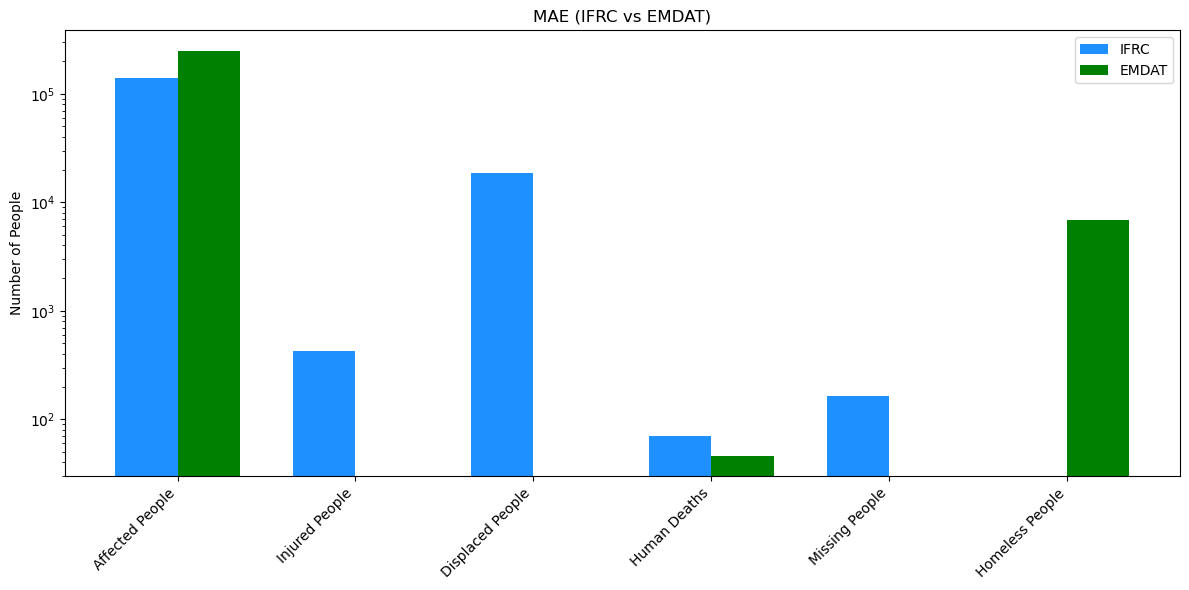

In [103]:
x = np.arange(len(mapping_impact_type.keys()))  # positions for bars
width = 0.35  # bar width

fig, ax = plt.subplots(figsize=(12,6))

# Define colors like in your previous example
colors_ifrc = ["skyblue", "dodgerblue"]      # all / perfect match
colors_emdat = ["lightgreen", "green"]       # all / perfect match

# IFRC bars
# ax.bar(x - width/2, nb_matched_ifrc, width, label="IFRC - all", color=colors_ifrc[0])
ax.bar(x - width/2, mae["ifrc_go"], width, label="IFRC", color=colors_ifrc[1])

# EMDAT bars
# ax.bar(x + width/2, nb_matched_emdat, width, label="EMDAT - all", color=colors_emdat[0])
ax.bar(x + width/2, mae["emdat"], width, label="EMDAT", color=colors_emdat[1])

# Labels
ax.set_xticks(x)
ax.set_xticklabels(mapping_impact_type.keys(), rotation=45, ha="right")
ax.set_ylabel("Number of People")
ax.set_title("MAE (IFRC vs EMDAT)")
ax.set_yscale("log")
ax.legend()

plt.tight_layout()
plt.show()

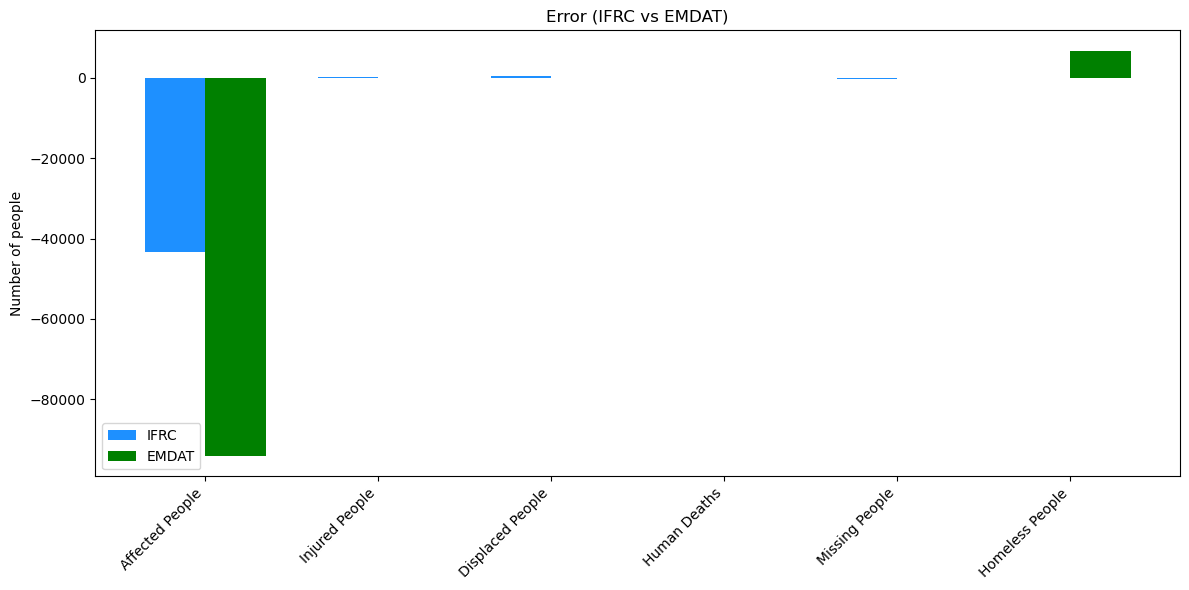

In [104]:
x = np.arange(len(mapping_impact_type.keys()))  # positions for bars
width = 0.35  # bar width

fig, ax = plt.subplots(figsize=(12,6))

# Define colors like in your previous example
colors_ifrc = ["skyblue", "dodgerblue"]      # all / perfect match
colors_emdat = ["lightgreen", "green"]       # all / perfect match

# IFRC bars
# ax.bar(x - width/2, nb_matched_ifrc, width, label="IFRC - all", color=colors_ifrc[0])
ax.bar(x - width/2, error["ifrc_go"], width, label="IFRC", color=colors_ifrc[1])

# EMDAT bars
# ax.bar(x + width/2, nb_matched_emdat, width, label="EMDAT - all", color=colors_emdat[0])
ax.bar(x + width/2, error["emdat"], width, label="EMDAT", color=colors_emdat[1])

# Labels
ax.set_xticks(x)
ax.set_xticklabels(mapping_impact_type.keys(), rotation=45, ha="right")
ax.set_ylabel("Number of people")
ax.set_title("Error (IFRC vs EMDAT)")
# ax.set_yscale("log")
ax.legend()

plt.tight_layout()
plt.show()

c:\Users\lhasbini\anaconda3\envs\ifrc_llm_311\Lib\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
c:\Users\lhasbini\anaconda3\envs\ifrc_llm_311\Lib\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


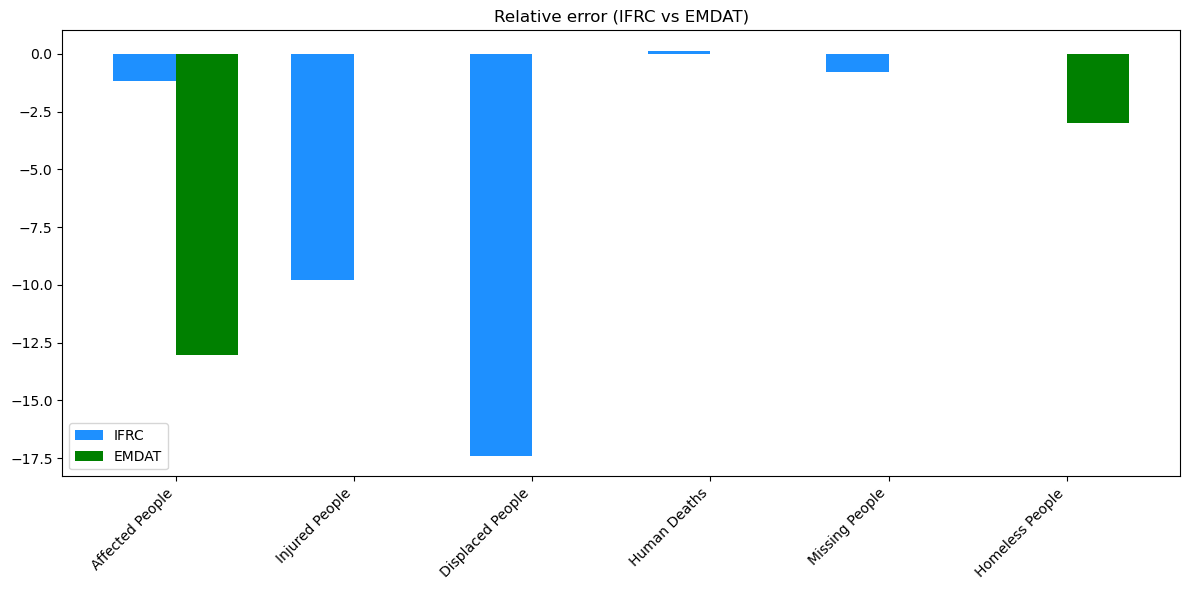

In [110]:
x = np.arange(len(mapping_impact_type.keys()))  # positions for bars
width = 0.35  # bar width

fig, ax = plt.subplots(figsize=(12,6))

# Define colors like in your previous example
colors_ifrc = ["skyblue", "dodgerblue"]      # all / perfect match
colors_emdat = ["lightgreen", "green"]       # all / perfect match

# IFRC bars
# ax.bar(x - width/2, nb_matched_ifrc, width, label="IFRC - all", color=colors_ifrc[0])
ax.bar(x - width/2, relative_error["ifrc_go"], width, label="IFRC", color=colors_ifrc[1])

# EMDAT bars
# ax.bar(x + width/2, nb_matched_emdat, width, label="EMDAT - all", color=colors_emdat[0])
ax.bar(x + width/2, relative_error["emdat"], width, label="EMDAT", color=colors_emdat[1])

# Labels
ax.set_xticks(x)
ax.set_xticklabels(mapping_impact_type.keys(), rotation=45, ha="right")
# ax.set_ylabel("Number of Appeals")
ax.set_title("Relative error (IFRC vs EMDAT)")
# ax.set_yscale("log")
ax.legend()

plt.tight_layout()
plt.show()

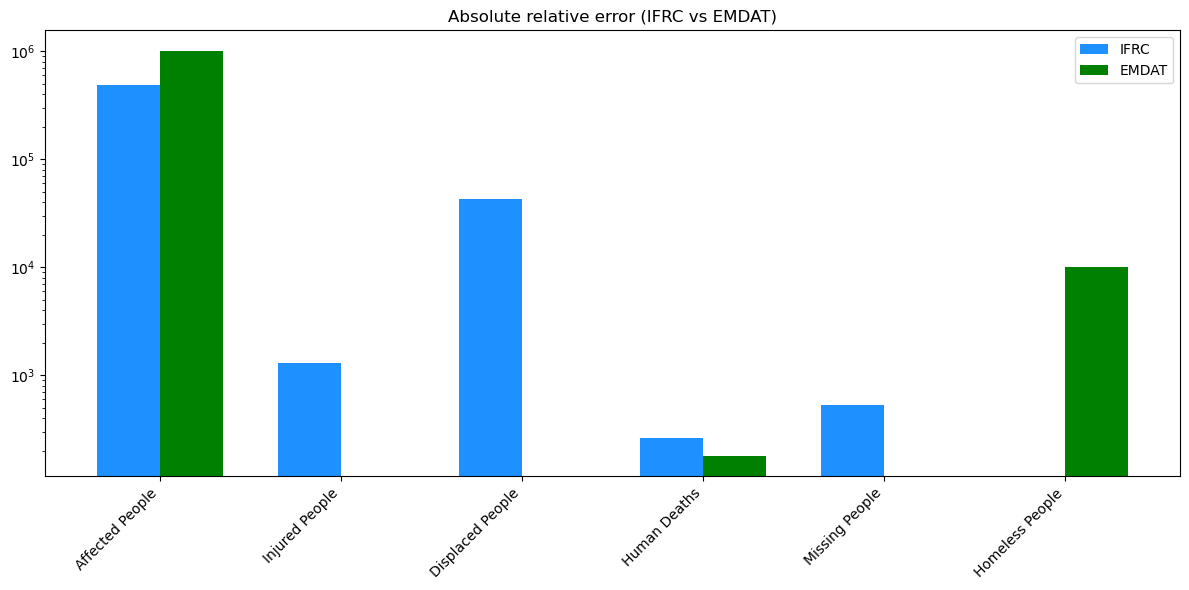

In [106]:
x = np.arange(len(mapping_impact_type.keys()))  # positions for bars
width = 0.35  # bar width

fig, ax = plt.subplots(figsize=(12,6))

# Define colors like in your previous example
colors_ifrc = ["skyblue", "dodgerblue"]      # all / perfect match
colors_emdat = ["lightgreen", "green"]       # all / perfect match

# IFRC bars
# ax.bar(x - width/2, nb_matched_ifrc, width, label="IFRC - all", color=colors_ifrc[0])
ax.bar(x - width/2, rmse["ifrc_go"], width, label="IFRC", color=colors_ifrc[1])

# EMDAT bars
# ax.bar(x + width/2, nb_matched_emdat, width, label="EMDAT - all", color=colors_emdat[0])
ax.bar(x + width/2, rmse["emdat"], width, label="EMDAT", color=colors_emdat[1])

# Labels
ax.set_xticks(x)
ax.set_xticklabels(mapping_impact_type.keys(), rotation=45, ha="right")
# ax.set_ylabel("Number of Appeals")
ax.set_title("Absolute relative error (IFRC vs EMDAT)")
ax.set_yscale("log")
ax.legend()

plt.tight_layout()
plt.show()

## Bar plot comparison

In [ ]:
from matplotlib.ticker import ScalarFormatter
def plot_em_dat_comparison(df_llm_geo_grp, df_labelled_geo_grp, df_emdat_linked, df_impact_ifrc_monty_appeal, df_go, appealCodelist, impactType, mapping_impact_type):
    # LLM EXTRACTED
    df1 = (
        df_llm_geo_grp[(df_llm_geo_grp["impactSubtype"] == impactType) &
                       (df_llm_geo_grp["appealCode"].isin(appealCodelist))]
        [["appealCode", "impactValue_final"]]
        .groupby("appealCode", as_index=False)
        .sum()
        .rename(columns={"impactValue_final": "LLM_extracted"})
    )

    # MANUALLY LABELLED
    df2 = (
        df_labelled_geo_grp[(df_labelled_geo_grp["impactSubtype"] == impactType) &
                       (df_labelled_geo_grp["appealCode"].isin(appealCodelist))]
        [["appealCode", "impactValue_final"]]
        .groupby("appealCode", as_index=False)
        .sum()
        .rename(columns={"impactValue_final": "Manual_labelling"})
    )

    # EMDAT MATCHING
    emdat_col = mapping_impact_type[impactType]["emdat"]
    if emdat_col is not None:
        df3 = (
            df_emdat_linked.loc[df_emdat_linked["appealCode"].isin(appealCodelist), ["appealCode", emdat_col]]
            .rename(columns={emdat_col: "EM-DAT"})
            .drop_duplicates()
        )
    else:
        # No EMDAT data available for this impact type
        df3 = pd.DataFrame({"appealCode": appealCodelist, "EM-DAT": [np.nan]*len(appealCodelist)})


    # IFRC MONTY
    df4 = (
        df_impact_ifrc_monty_appeal[(df_impact_ifrc_monty_appeal["impact_type"] == mapping_impact_type[impactType]["ifrc_monty"])&
                                    (df_impact_ifrc_monty_appeal["appealCode"].isin(appealCodelist))]
        [["appealCode", "impact_value"]]
        .groupby("appealCode", as_index=False)
        .sum()
        .rename(columns={"impact_value": "IFRC_Monty"})
    )

    # IFRC GO
    df5 = df_go[["appealCode", mapping_impact_type[impactType]["ifrc_go"]]].loc[df_go["appealCode"].isin(appealCodelist)].rename(
        columns={mapping_impact_type[impactType]["ifrc_go"] : "IFRC_GO"}
    )

    # --- Merge all together ---
    df_all = df1.merge(df2, on="appealCode", how="outer").merge(df3, on="appealCode", how="outer").merge(df4, on="appealCode", how="outer").merge(df5, on="appealCode", how="outer")

    # --- Plot ---
    ax = df_all.set_index("appealCode").plot(
        kind="bar", figsize=(12, 6), width=0.8, logy=True
    )

    # Format y-axis to switch to scientific notation for large values
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-3, 3))  # auto switch if values <1e-3 or >1e3
    ax.yaxis.set_major_formatter(formatter)

    plt.title(f"Number of {impactType} by Appeal Code (Comparison of Sources)")
    plt.xlabel("Appeal Code")
    plt.ylabel(f"Number of {impactType}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return df_all


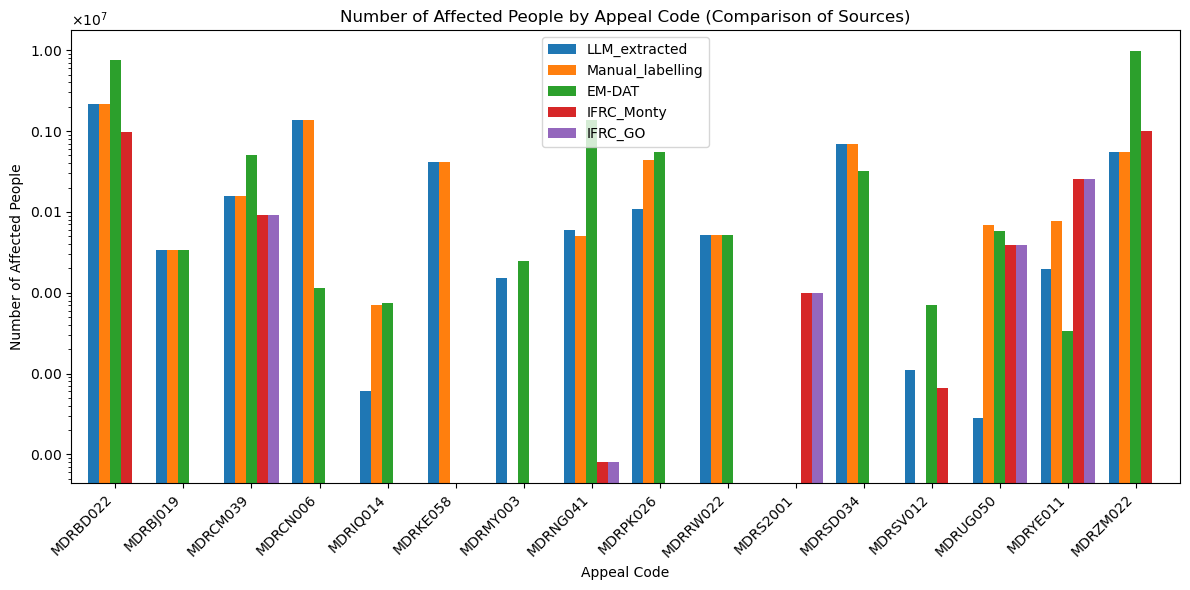

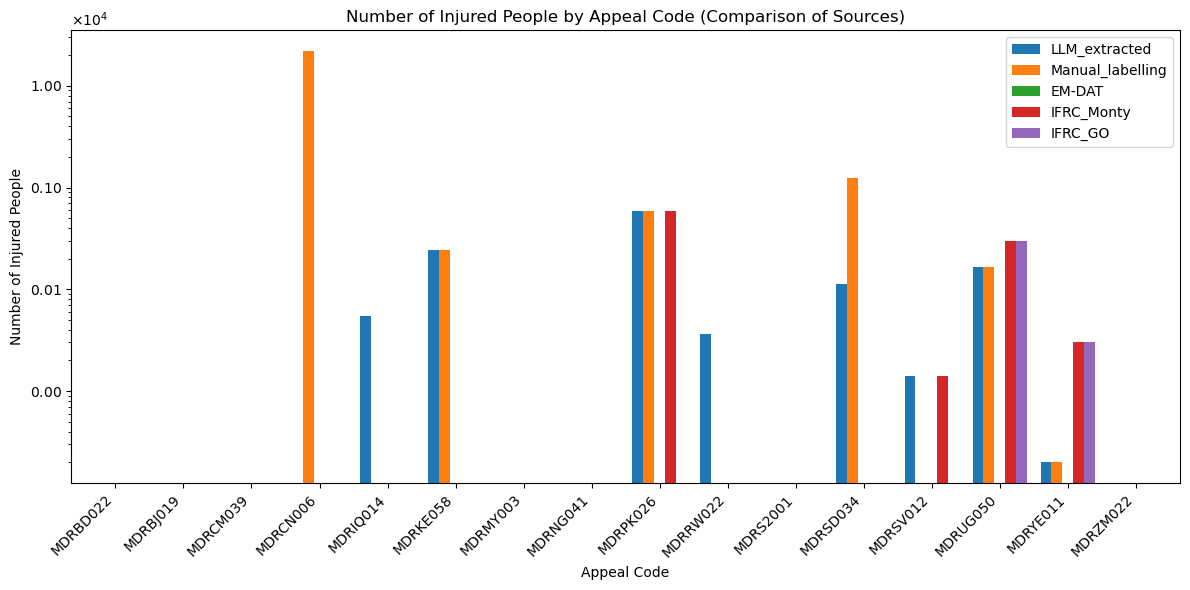

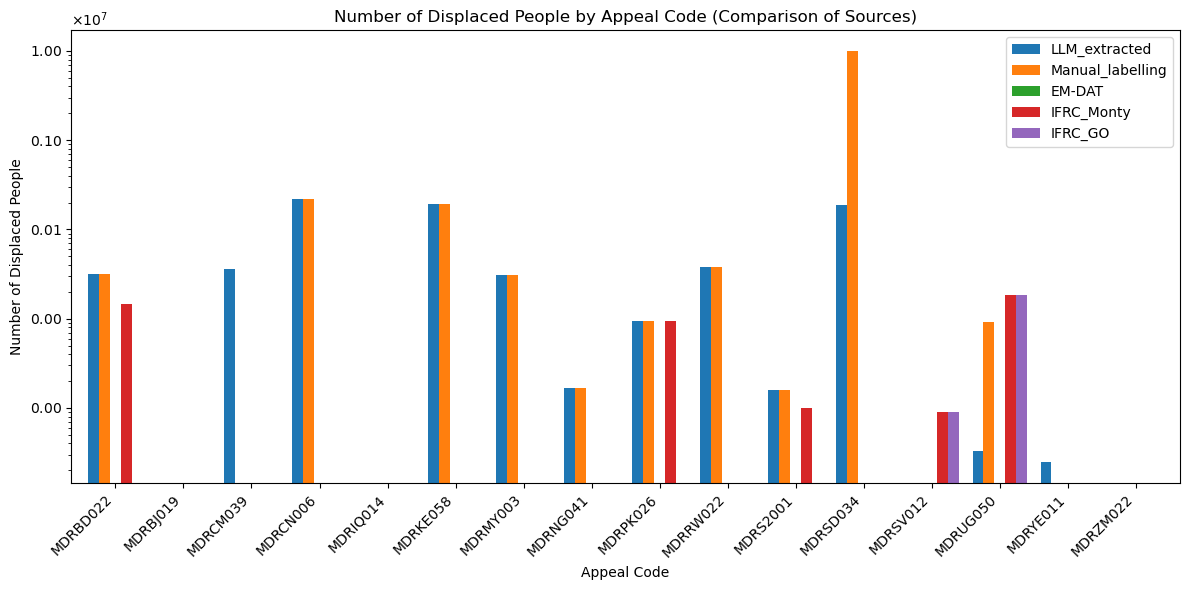

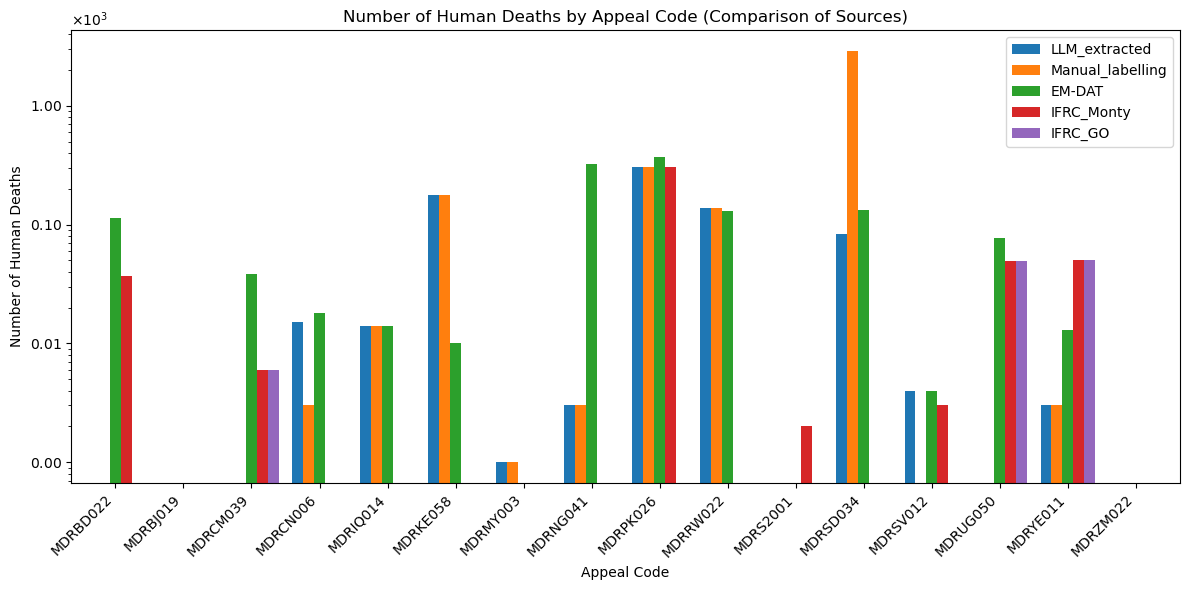

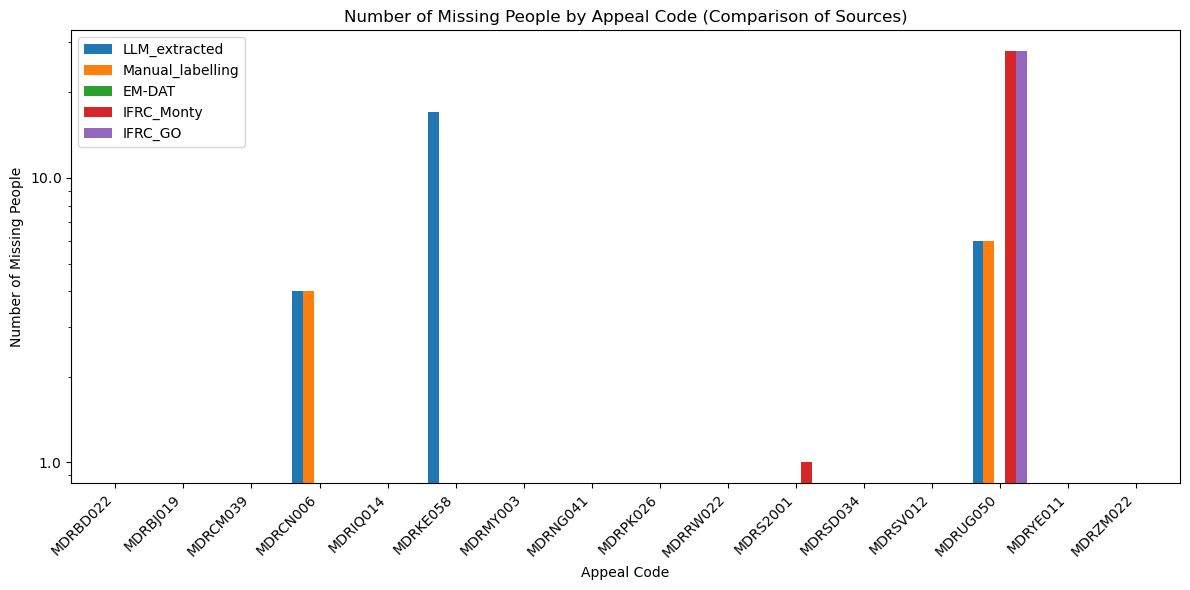

In [59]:
for impactType in list(mapping_impact_type.keys()) :
    df_plot_data = plot_em_dat_comparison(df_llm_geo_grp, df_labelled_geo_grp, df_llm_linked, df_impact_ifrc_monty_appeal, df_go_all, df_llm_geo_grp.appealCode.unique(), impactType, mapping_impact_type)

## Bar plot relative error 

In [ ]:
from matplotlib.ticker import ScalarFormatter

def plot_em_dat_comparison_relative(df_llm_geo_grp, df_labelled_geo_grp, df_emdat_linked, df_impact_ifrc_monty_appeal, df_go, appealCodelist, impactType, mapping_impact_type):
    linthresh=0.1
    margin=1.15

    # --- LLM EXTRACTED (reference baseline) ---
    df1 = (
        df_llm_geo_grp[(df_llm_geo_grp["impactSubtype"] == impactType) &
                       (df_llm_geo_grp["appealCode"].isin(appealCodelist))]
        [["appealCode", "impactValue_final"]]
        .groupby("appealCode", as_index=False)
        .sum()
        .rename(columns={"impactValue_final": "LLM_extracted"})
    )

    # --- MANUALLY LABELLED ---
    df2 = (
        df_labelled_geo_grp[(df_labelled_geo_grp["impactSubtype"] == impactType) &
                            (df_labelled_geo_grp["appealCode"].isin(appealCodelist))]
        [["appealCode", "impactValue_final"]]
        .groupby("appealCode", as_index=False)
        .sum()
        .rename(columns={"impactValue_final": "Manual_labelling"})
    )

    # --- EMDAT MATCHING ---
    emdat_col = mapping_impact_type[impactType]["emdat"]
    if emdat_col is not None:
        df3 = (
            df_emdat_linked.loc[df_emdat_linked["appealCode"].isin(appealCodelist), ["appealCode", emdat_col]]
            .rename(columns={emdat_col: "EM-DAT"})
            .drop_duplicates()
        )
    else:
        df3 = pd.DataFrame({"appealCode": appealCodelist, "EM-DAT": [np.nan]*len(appealCodelist)})

    # --- IFRC MONTY ---
    df4 = (
        df_impact_ifrc_monty_appeal[(df_impact_ifrc_monty_appeal["impact_type"] == mapping_impact_type[impactType]["ifrc_monty"])&
                                    (df_impact_ifrc_monty_appeal["appealCode"].isin(appealCodelist))]
        [["appealCode", "impact_value"]]
        .groupby("appealCode", as_index=False)
        .sum()
        .rename(columns={"impact_value": "IFRC_Monty"})
    )

    # --- IFRC GO ---
    df5 = df_go[["appealCode", mapping_impact_type[impactType]["ifrc_go"]]].loc[df_go["appealCode"].isin(appealCodelist)].rename(
        columns={mapping_impact_type[impactType]["ifrc_go"] : "IFRC_GO"}
    )

    # --- Merge all together ---
    df_all = df1.merge(df2, on="appealCode", how="outer") \
                .merge(df3, on="appealCode", how="outer") \
                .merge(df4, on="appealCode", how="outer") \
                .merge(df5, on="appealCode", how="outer")

    # --- Compute relative error with respect to LLM_extracted ---
    ref = df_all["LLM_extracted"]
    df_rel = df_all.set_index("appealCode").drop(columns=["LLM_extracted"])
    df_rel = (df_rel.sub(ref.values, axis=0)).div(ref.values, axis=0)

    # --- Plot ---
    ax = df_rel.plot(
        kind="bar", figsize=(12, 6), width=0.8
    )

    # --- Symlog y-scale (works for ± values) ---
    ax.set_yscale("symlog", linthresh=linthresh)  # linear near 0, log beyond

    # --- Center around 0 with symmetric limits ---
    max_abs = np.nanmax(np.abs(df_rel.values))
    if not np.isfinite(max_abs) or max_abs == 0:
        max_abs = 1.0
    ymax = max(linthresh, max_abs) * margin
    ax.set_ylim(-ymax, ymax)

    # --- Horizontal lines at each power of 10 (±) within current limits ---
    # compute exponents covered by current limits, but not below linthresh
    lim = ax.get_ylim()
    max_abs_lim = max(abs(lim[0]), abs(lim[1]))
    k_max = int(np.floor(np.log10(max_abs_lim)))
    k_min = int(np.ceil(np.log10(linthresh)))  # start at boundary of log region
    if k_max >= k_min:
        for k in range(k_min, k_max + 1):
            val = 10.0 ** k
            ax.axhline(val,  color="gray", linestyle="--", linewidth=0.8, alpha=0.7, zorder=0)
            ax.axhline(-val, color="gray", linestyle="--", linewidth=0.8, alpha=0.7, zorder=0)

    # Zero line
    ax.axhline(0, color="black", linewidth=1, zorder=1)

    plt.axhline(0, color="black", linewidth=1)
    plt.title(f"Relative Error vs LLM-extracted for {impactType}")
    plt.xlabel("Appeal Code")
    plt.ylabel("Relative Error (vs LLM-extracted)")

    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return df_rel.reset_index()


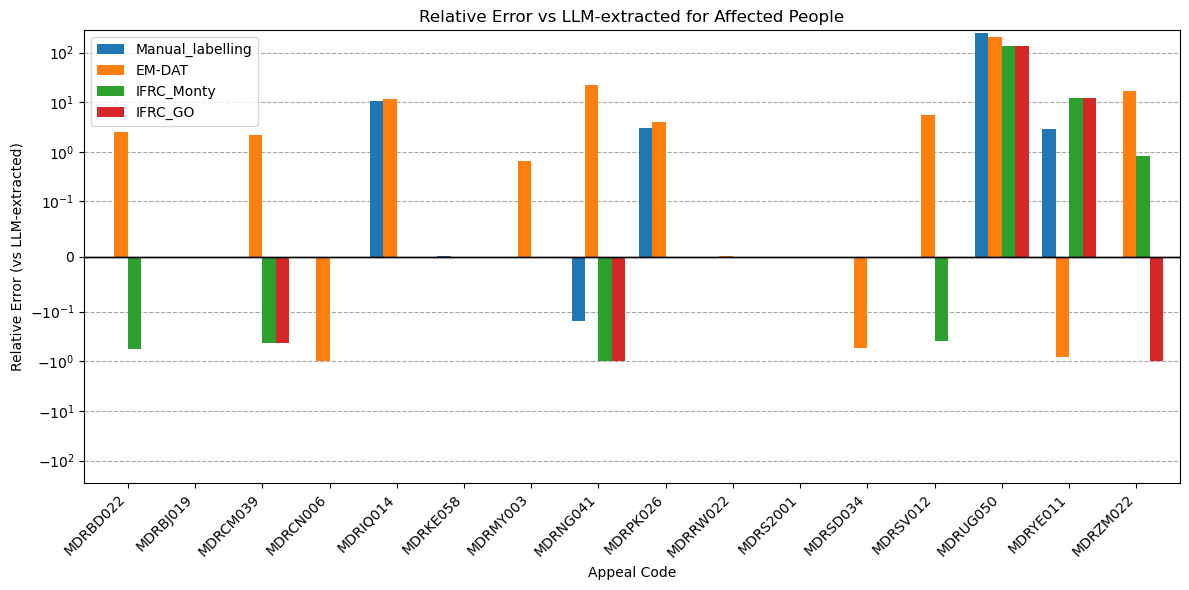

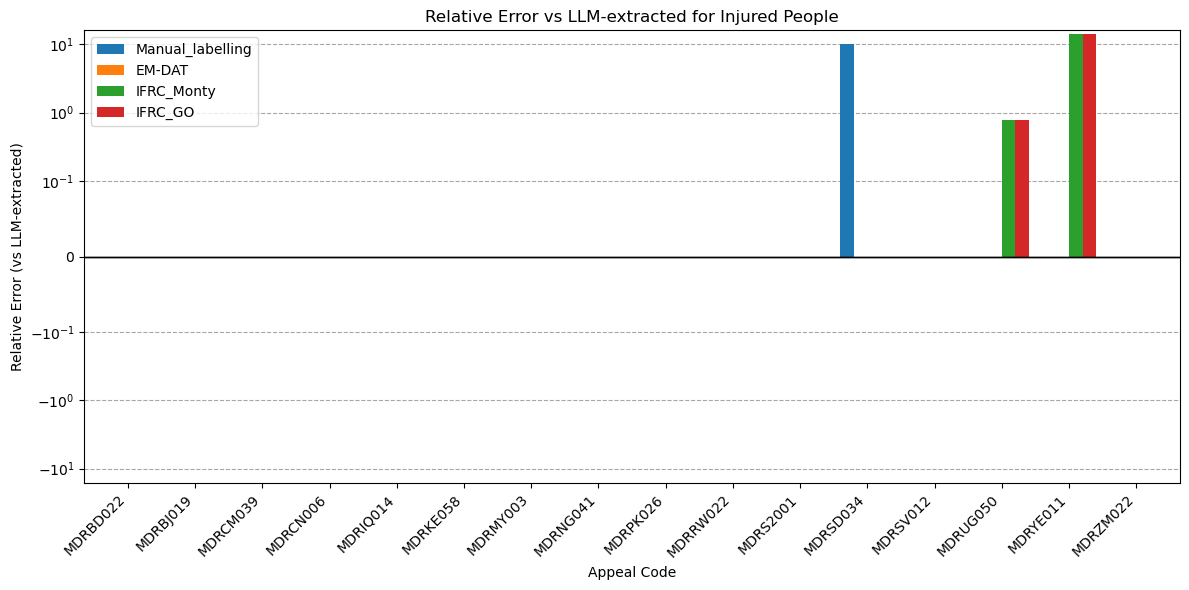

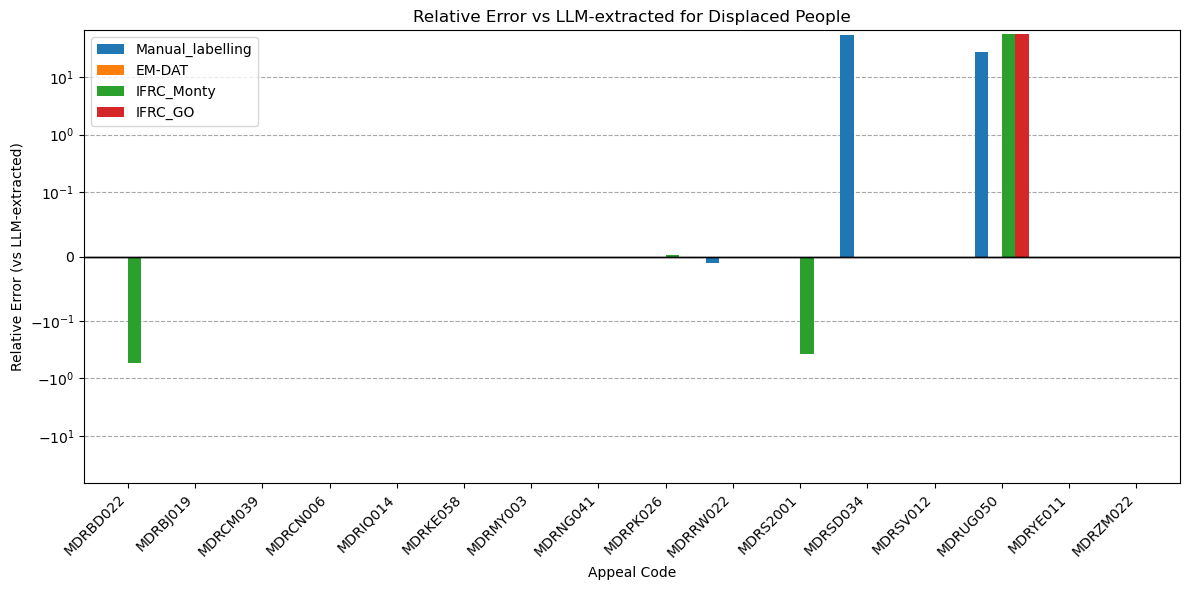

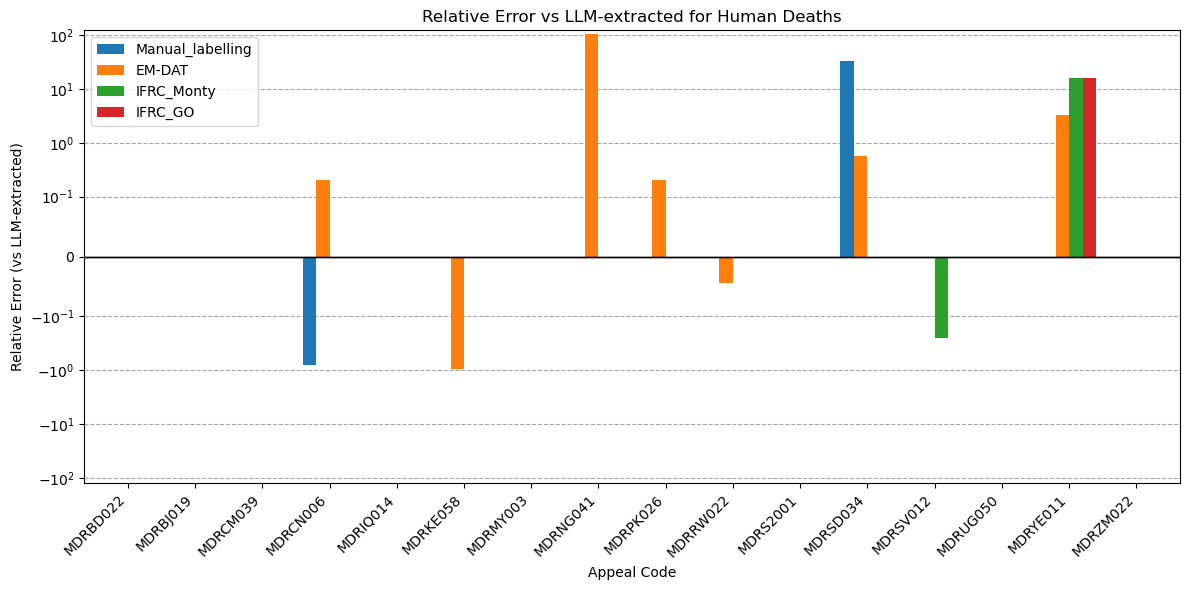

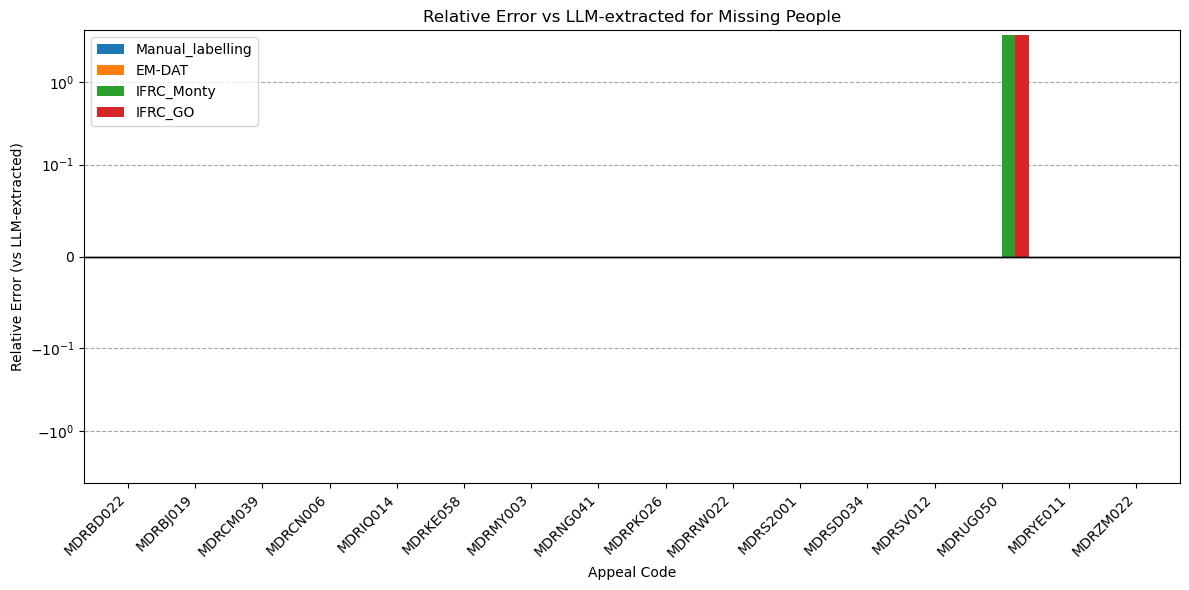

In [68]:
for impactType in list(mapping_impact_type.keys()) :
    df_plot_data = plot_em_dat_comparison_relative(df_llm_geo_grp, df_labelled_geo_grp, df_llm_linked, df_impact_ifrc_monty_appeal, df_go_all, df_llm_geo_grp.appealCode.unique(), impactType, mapping_impact_type)